In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


              precision    recall  f1-score   support

     healthy       0.61      0.97      0.75        29
       other       0.71      0.43      0.53        28
        pale       0.69      0.64      0.67        14
     spotted       0.81      0.62      0.70        21

    accuracy                           0.67        92
   macro avg       0.70      0.66      0.66        92
weighted avg       0.70      0.67      0.66        92



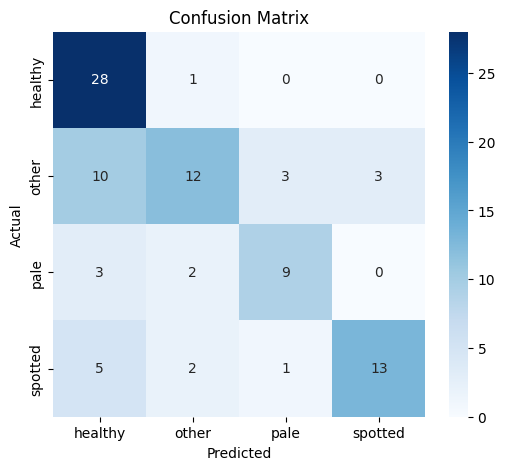

In [9]:
import cv2
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_PATH = '/content/drive/MyDrive/comb_dataset_nopad'

def extract_features(split):
    X, y = [], []
    split_path = os.path.join(DATASET_PATH, split)

    for class_name in os.listdir(split_path):
        class_dir = os.path.join(split_path, class_name)

        if not os.path.isdir(class_dir):
            continue

        for filename in os.listdir(class_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_dir, filename)
                img = cv2.imread(img_path)

                if img is None:
                    continue

                hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
                H, S, V = cv2.split(hsv_img)

                mask = cv2.inRange(hsv_img, np.array([0, 1, 1]), np.array([179, 255, 255]))

                if np.count_nonzero(mask) == 0:
                    continue

                mean_H_arr, std_H_arr = cv2.meanStdDev(H, mask)
                mean_S_arr, std_S_arr = cv2.meanStdDev(S, mask)
                mean_V_arr, std_V_arr = cv2.meanStdDev(V, mask)

                mean_H = mean_H_arr[0][0]
                std_H = std_H_arr[0][0]
                mean_S = mean_S_arr[0][0]
                std_S = std_S_arr[0][0]
                mean_V = mean_V_arr[0][0]
                std_V = std_V_arr[0][0]

                X.append([mean_H, std_H, mean_S, std_S, mean_V, std_V])
                y.append(class_name)

    return np.array(X), np.array(y)


# Extract splits
X_train, y_train = extract_features("train")
X_val, y_val = extract_features("val")


# Encode labels
le = LabelEncoder()
le.fit(y_train)

y_train = le.transform(y_train)
y_val = le.transform(y_val)
#y_test = le.transform(y_test)

# Scale features (fit ONLY on train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
#X_test = scaler.transform(X_test)

# Train model
classifier = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

classifier.fit(X_train, y_train)

# Evaluate on val set
y_pred = classifier.predict(X_val)

print(classification_report(y_val, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [10]:
from sklearn.metrics import log_loss, accuracy_score

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, classifier.predict(X_train))
print(f"Training Accuracy: {train_accuracy:.4f}")

# Calculate validation accuracy
val_accuracy = accuracy_score(y_val, classifier.predict(X_val))
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Calculate training log loss (requires probability predictions)
train_log_loss = log_loss(y_train, classifier.predict_proba(X_train))
print(f"Training Log Loss: {train_log_loss:.4f}")

# Calculate validation log loss
val_log_loss = log_loss(y_val, classifier.predict_proba(X_val))
print(f"Validation Log Loss: {val_log_loss:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.6739
Training Log Loss: 0.1356
Validation Log Loss: 1.2384


These metrics represent the final performance of the trained `RandomForestClassifier` on your training and validation datasets. Since `RandomForestClassifier` is not trained iteratively, there isn't a progression of these metrics to plot over 'epochs' or similar training steps.

/tmp/ipykernel_24039/3016441952.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracy_labels, y=accuracy_values, palette='viridis')


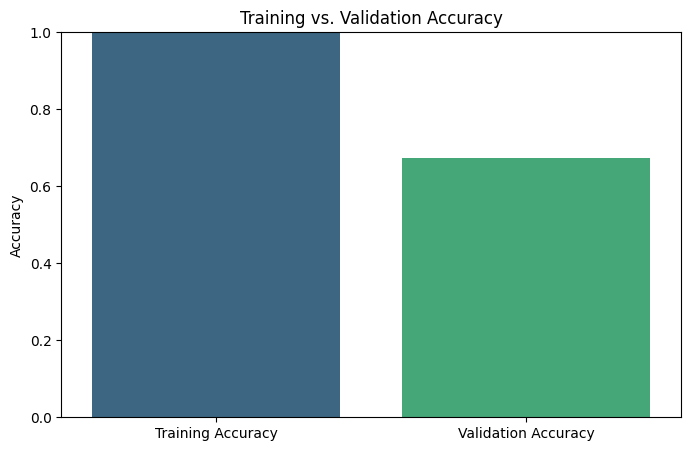

/tmp/ipykernel_24039/3016441952.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_labels, y=loss_values, palette='magma')


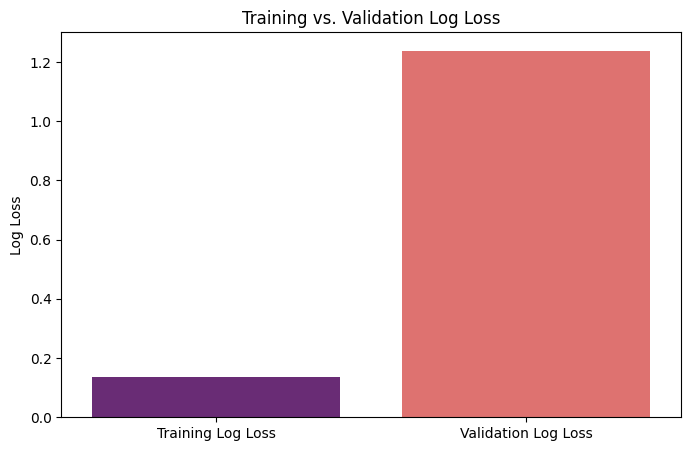

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting accuracy
accuracy_labels = ['Training Accuracy', 'Validation Accuracy']
accuracy_values = [train_accuracy, val_accuracy]

plt.figure(figsize=(8, 5))
sns.barplot(x=accuracy_labels, y=accuracy_values, palette='viridis')
plt.title('Training vs. Validation Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.show()

# Data for plotting log loss
loss_labels = ['Training Log Loss', 'Validation Log Loss']
loss_values = [train_log_loss, val_log_loss]

plt.figure(figsize=(8, 5))
sns.barplot(x=loss_labels, y=loss_values, palette='magma')
plt.title('Training vs. Validation Log Loss')
plt.ylabel('Log Loss')
plt.show()

              precision    recall  f1-score   support

     healthy       0.69      0.83      0.75        29
       other       0.59      0.46      0.52        28
        pale       0.45      0.64      0.53        14
     spotted       0.60      0.43      0.50        21

    accuracy                           0.60        92
   macro avg       0.58      0.59      0.57        92
weighted avg       0.60      0.60      0.59        92



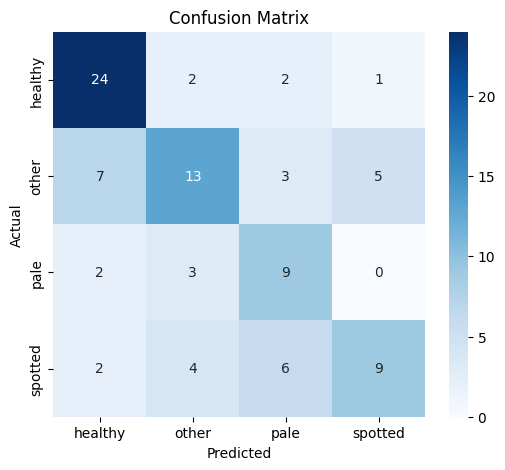

SVC Training Accuracy: 0.7851
SVC Validation Accuracy: 0.5978
SVC Training Log Loss: 0.5307
SVC Validation Log Loss: 1.0377


In [12]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, log_loss, accuracy_score

classifier = SVC(
    kernel='rbf',
    class_weight="balanced",
    random_state=42,
    probability=True # Added probability=True for log loss calculation
)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_val)

print(classification_report(y_val, y_pred, target_names=[str(c) for c in le.classes_]))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Calculate training accuracy for SVC
train_accuracy_svc = accuracy_score(y_train, classifier.predict(X_train))
print(f"SVC Training Accuracy: {train_accuracy_svc:.4f}")

# Calculate validation accuracy for SVC
val_accuracy_svc = accuracy_score(y_val, classifier.predict(X_val))
print(f"SVC Validation Accuracy: {val_accuracy_svc:.4f}")

# Calculate training log loss for SVC
train_log_loss_svc = log_loss(y_train, classifier.predict_proba(X_train))
print(f"SVC Training Log Loss: {train_log_loss_svc:.4f}")

# Calculate validation log loss for SVC
val_log_loss_svc = log_loss(y_val, classifier.predict_proba(X_val))
print(f"SVC Validation Log Loss: {val_log_loss_svc:.4f}")

In [ ]:
from google.colab import drive
import os
import numpy as np

drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/hsv_data'
os.makedirs(save_dir, exist_ok=True)

np.savez(os.path.join(save_dir, 'train_hsv.npz'),
         X_train=X_train,
         y_train=y_train)

np.savez(os.path.join(save_dir, 'val_hsv.npz'),
         X_val=X_val,
         y_val=y_val)

np.save(os.path.join(save_dir, 'label_classes.npy'), le.classes_)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
